In [2]:
import os
import json
import warnings
import numpy as np
import sympy as sp
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
MODELSDIR  = CONFIGS['filepaths']['models']
PREDSDIR   = CONFIGS['filepaths']['predictions']
MODELS     = CONFIGS['experiments']
SEEDS      = MODELS['sr']['seeds']
SPLIT      = 'test'
DESCRIPTIONS = {}
for _name,_rc in MODELS['pod']['runs'].items():
    DESCRIPTIONS[_name] = _rc.get('description',_name)
for _name,_rc in MODELS['nn']['runs'].items():
    DESCRIPTIONS[_name] = _rc.get('description',_name)
for _name,_eqspec in MODELS['sr'].get('optimizedeqs',{}).items():
    DESCRIPTIONS[_name] = _eqspec.get('description',_name)

MODELDICT  = {
    'pod_bl':      {'label':DESCRIPTIONS.get('pod_bl','POD-BL'),         'color':'k',       'marker':'x'},
    'nn_bl':       {'label':DESCRIPTIONS.get('nn_bl','NN-BL'),            'color':'#fa862d', 'marker':'D'},
    'nn_full':     {'label':DESCRIPTIONS.get('nn_full','NN-FULL'),        'color':'#1b2c63', 'marker':'D'},
    'nn_nonparam': {'label':DESCRIPTIONS.get('nn_nonparam','NN-NONPARAM'),'color':'#245ba7', 'marker':'D'},
    'nn_gauss':    {'label':DESCRIPTIONS.get('nn_gauss','NN-GAUSS'),      'color':'#5ca7db', 'marker':'D'},
    'sr_bl':       {'label':DESCRIPTIONS.get('sr_bl','SR-BL'),            'color':'#c41d24', 'marker':'o'},
    'sr_lo':       {'label':DESCRIPTIONS.get('sr_lo','SR-LO'),        'color':'#a3ddf7', 'marker':'o'},

    'sr_med':       {'label':DESCRIPTIONS.get('sr_med','SR-MED'),        'color':'#a3ddf7', 'marker':'o'},

    'sr_hi':       {'label':DESCRIPTIONS.get('sr_hi','SR-HI'),        'color':'#a3ddf7', 'marker':'o'},
}

In [4]:
def get_r2(ytrue,ypred,dims=None):
    dims  = list(ytrue.dims) if dims is None else dims
    ssres = ((ytrue-ypred)**2).sum(dim=dims,skipna=True)
    sstot = ((ytrue-ytrue.mean(dim=dims,skipna=True))**2).sum(dim=dims,skipna=True)
    return float(1-ssres/sstot)

def get_mse(ytrue,ypred,dims=None):
    dims = list(ytrue.dims) if dims is None else dims
    return float(((ytrue-ypred)**2).mean(dim=dims,skipna=True))

def get_nn_complexity(kind,nfieldvars,nlevs,nlocalvars):
    def nparams(nfeatures):
        return (nfeatures*256)+256+(256*128)+128+(128*64)+64+(64*32)+32+(32*1)+1
    if kind=='baseline':
        return nparams(nfieldvars*nlevs+nlocalvars)
    elif kind=='nonparametric':
        return nfieldvars*nlevs+nparams(nfieldvars+nlocalvars)
    elif kind=='parametric':
        return 2*nfieldvars+nparams(nfieldvars+nlocalvars)

def get_mse_at_r2(ytrue,r2_target=0.5,dims=None):
    dims  = list(ytrue.dims) if dims is None else dims
    sstot = ((ytrue-ytrue.mean(dim=dims,skipna=True))**2).sum(dim=dims,skipna=True)
    n     = ytrue.count(dim=dims)
    return float((1-r2_target)*sstot/n)

def pareto_front(records):
    ordered,front,best = sorted(records,key=lambda r:r['mse']),[],np.inf
    for r in ordered:
        if r['nparams'] < best:
            front.append(r)
            best = r['nparams']
    return sorted(front,key=lambda r:r['nparams'])

def prettify_eq(eqstr):
    allvars = ['rh','thetae','thetaestar','lf','shf','lhf']
    varsyms = {name:sp.Symbol(name) for name in allvars}
    symbolnames = {
        varsyms['rh']:r'\widehat{RH}',
        varsyms['thetae']:r'\widehat{\theta_e}',
        varsyms['thetaestar']:r'\widehat{\theta_e^*}',
        varsyms['lf']:r'\mathrm{LF}',
        varsyms['shf']:r'\mathrm{SHF}',
        varsyms['lhf']:r'\mathrm{LHF}'}
    ns = {**varsyms,
          'cube':lambda x:x**3,'square':lambda x:x**2,'neg':lambda x:-x,
          'sqrt':sp.sqrt,'exp':sp.exp,'log':sp.log,'abs':sp.Abs,'cos':sp.cos,'sin':sp.sin}
    try:
        expr = eval(eqstr,{'__builtins__':{}},ns)
        for atom in list(expr.atoms(sp.Float)):
            expr = expr.subs(atom,sp.Float(f'{float(atom):.3g}'))
        return f'${sp.latex(expr,symbol_names=symbolnames)}$'
    except Exception:
        return eqstr

In [5]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truetp = ds.tp.load()

with xr.open_dataset(os.path.join(SPLITSDIR,'norm_train.h5'),engine='h5netcdf') as ds:
    firstvar = next(iter(MODELS['nn']['runs'].values()))['fieldvars'][0]
    nsigs    = ds.sizes['sig'] if 'sig' in ds[firstvar].dims else 1

def get_target_nparams(name):
    if name=='pod_bl':
        with np.load(os.path.join(MODELSDIR,'pod',f'{name}.npz')) as d:
            return int(d['nparams'])
    if name in MODELS['nn']['runs']:
        config = MODELS['nn']['runs'][name]
        return get_nn_complexity(config['kind'],len(config['fieldvars']),nsigs,len(config.get('localvars',[])))
    if name in MODELS['sr'].get('optimizedeqs',{}):
        return MODELS['sr']['optimizedeqs'][name]['refcomplexity']
    return None

targetresults = {}
for name in MODELDICT:
    filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(filepath):
        print(f'Missing predictions: {name}')
        continue
    with xr.open_dataset(filepath) as ds:
        predtp = ds.tp.load()
    if 'seed' in predtp.dims:
        predtp = predtp.mean('seed')
    if 'complexity' in predtp.dims:
        predtp = predtp.isel(complexity=0)
    ytrue,ypred = xr.align(truetp,predtp,join='inner')
    targetresults[name] = (ytrue.squeeze(),ypred.squeeze())

targetr2seeds = {}
for name in MODELDICT:
    if name not in targetresults:
        continue
    filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    with xr.open_dataset(filepath) as ds:
        predtp = ds.tp.load()
    if 'seed' not in predtp.dims or predtp.sizes.get('seed',1) < 2:
        continue
    ytrue = targetresults[name][0]
    targetr2seeds[name] = np.array([
        get_r2(ytrue, xr.align(truetp, predtp.sel(seed=sid).squeeze(), join='inner')[1].squeeze())
        for sid in predtp.seed.values])

paretoresults = {}
for name in MODELS['sr']['runs']:
    filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(filepath):
        continue
    with xr.open_dataset(filepath) as ds:
        predtp = ds.tp.load()
    if 'seed' in predtp.dims:
        predtp = predtp.mean('seed')
    if 'complexity' not in predtp.dims:
        continue
    ytrue,ypred = xr.align(truetp,predtp,join='inner')
    paretoresults[name] = (ytrue.squeeze(),ypred.squeeze())

print(f'Target models loaded: {len(targetresults)}/{len(MODELDICT)}')
print(f'Per-seed R² computed for: {list(targetr2seeds.keys())}')
print(f'Pareto runs loaded:   {len(paretoresults)}')

Target models loaded: 9/9
Per-seed R² computed for: ['nn_bl', 'nn_full', 'nn_nonparam', 'nn_gauss']
Pareto runs loaded:   0


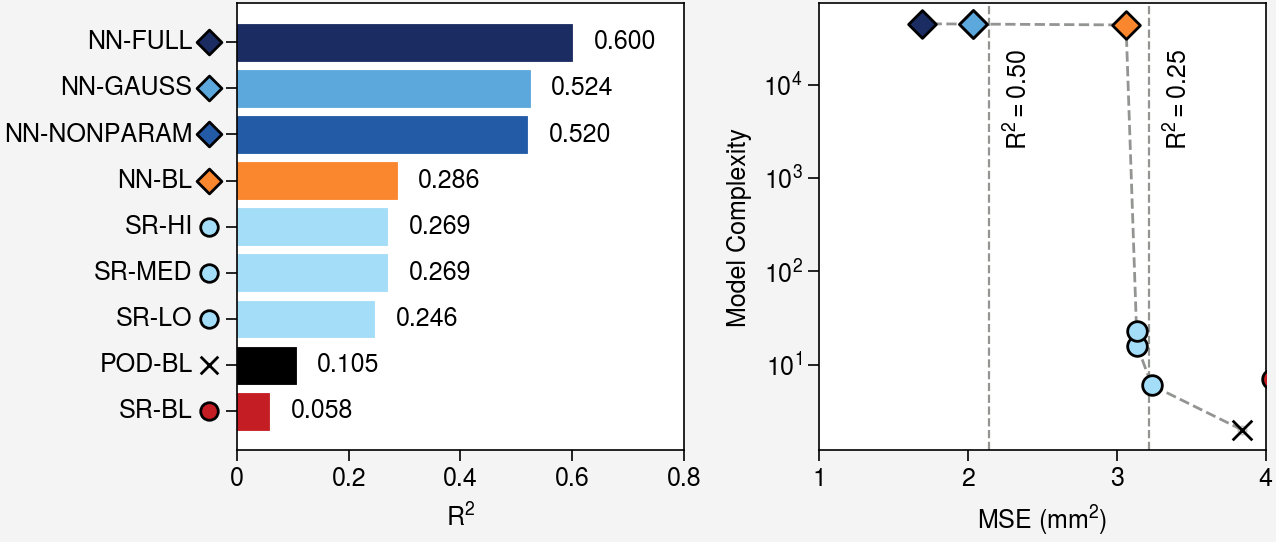

In [6]:
targetr2      = {name:float(targetr2seeds[name].mean()) if name in targetr2seeds else get_r2(*targetresults[name]) for name in targetresults}
targetmse     = {name:get_mse(*targetresults[name]) for name in targetresults}
targetnparams = {name:get_target_nparams(name) for name in targetresults}

frontierrecords = []
for run,(ytrue,ypred) in paretoresults.items():
    for c in ypred.complexity.values:
        frontierrecords.append(dict(mse=get_mse(ytrue,ypred.sel(complexity=int(c))),nparams=int(c)))
for name in MODELDICT:
    if name not in targetresults or targetnparams.get(name) is None:
        continue
    frontierrecords.append(dict(mse=targetmse[name],nparams=targetnparams[name]))
frontier = pareto_front(frontierrecords) if frontierrecords else []
refytrue = next(iter(targetresults.values()))[0]
mserefs  = {r2:get_mse_at_r2(refytrue,r2_target=r2) for r2 in [0.25,0.5]}

rows   = [(name,targetr2[name]) for name in MODELDICT if name in targetr2]
rows.sort(key=lambda x: x[1])
labels = [MODELDICT[name]['label'] for name,_ in rows]
colors = [MODELDICT[name]['color'] for name,_ in rows]
r2s    = [targetr2[name] for name,_ in rows]

fig,axs = pplt.subplots(ncols=2,figwidth=6.5,refwidth=2,share=False,tight=True)
axs[0].barh(labels,r2s,color=colors)

for i,(name, _) in enumerate(rows): 
    info = MODELDICT[name] 
    axs[0].scatter(-0.05,i,marker=info['marker'],edgecolors='k',linewidths=1,
                   color=info['color'],markersize=40,clip_on=False)

axs[0].set_yticks(range(len(labels)))
axs[0].set_yticklabels([])

for i,label in enumerate(labels):
    axs[0].text(-0.08,i,label,va='center',ha='right')
    
for i,(name,_) in enumerate(rows):
    r2 = targetr2[name]
    axs[0].text(max(r2+0.15,0.01),i,f'{r2:.3f}',va='center',ha='right')
axs[0].format(grid=False,xlabel=r'$R^2$',xlim=(0,0.8))

if frontierrecords:
    axs[1].scatter([r['mse'] for r in frontierrecords],[r['nparams'] for r in frontierrecords],color='gray',alpha=0.35,zorder=2,s=10)
    if len(frontier)>1:
        axs[1].plot([r['mse'] for r in frontier],[r['nparams'] for r in frontier],color='gray',linestyle='--',lw=1,zorder=3,label='Pareto Frontier')

for name,info in MODELDICT.items():
    if name not in targetresults or targetnparams.get(name) is None:
        continue
    axs[1].scatter(targetmse[name],targetnparams[name],color=info['color'],marker=info['marker'],
                   s=50,zorder=6,label=info['label'],edgecolors='k',linewidths=1)

for r2,mse in mserefs.items():
    axs[1].axvline(mse,color='gray',linestyle='--',linewidth=0.8)
    axs[1].text(mse+0.1,0.9,rf'$R^2={r2:.2f}$',rotation=90,va='top',ha='left',transform=axs[1].get_xaxis_transform())

axs[1].format(grid=False,xlabel=r'MSE (mm$^2$)',xlim=(1,4),ylabel='Model Complexity',yscale='log',yformatter='log')
# axs[1].legend(loc='r',ncols=1)
pplt.show()
fig.save('../figs/fig_1.jpg')